Roll Number: CH.SC.U4CSE24112
Name: Deepak SN
LOGISTIC REGRESSION 2

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]
df = pd.read_csv(url, names=columns)
print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [3]:
print(df.shape)
print(df.info())
print(df.describe())

(768, 9)
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std      

In [4]:
print("Zero values in each column:")
print((df == 0).sum())

Zero values in each column:
Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


In [5]:
medical_columns = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]
df[medical_columns] = df[medical_columns].replace(0, pd.NA)

df[medical_columns] = df[medical_columns].fillna(
    df[medical_columns].median()
)
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [6]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']
print("Features:")
print(X.head())
print("\nTarget:")
print(y.head())

Features:
   Pregnancies Glucose BloodPressure SkinThickness Insulin   BMI  \
0            6     148            72            35   125.0  33.6   
1            1      85            66            29   125.0  26.6   
2            8     183            64          29.0   125.0  23.3   
3            1      89            66            23      94  28.1   
4            0     137            40            35     168  43.1   

   DiabetesPedigreeFunction  Age  
0                     0.627   50  
1                     0.351   31  
2                     0.672   32  
3                     0.167   21  
4                     2.288   33  

Target:
0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (614, 8)
Testing data: (154, 8)


In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Features standardized successfully.")

Features standardized successfully.


In [14]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)
print("model trained successfully")

model trained successfully


In [13]:
y_pred = model.predict(X_test_scaled)
print("Predictions:")
print(y_pred)

Predictions:
[0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 1 1 0 0 1 0 1 1 0 0 0 0 1 1 1 1 1 1 1
 0 0 0 0 1 1 0 0 1 1 0 0 1 0 1 1 0 0 0 1 0 0 1 1 0 0 0 0 1 0 1 0 1 1 0 0 0
 0 0 0 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 1 1 0 0 1 0 1 0 1 1 1 0 0 1 0 0 0
 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0 0
 0 1 0 0 0 0]


In [15]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Accuracy percentage:", round(accuracy * 100, 2), "%")

Accuracy: 0.7532467532467533
Accuracy percentage: 75.32 %


In [16]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[82 17]
 [21 34]]


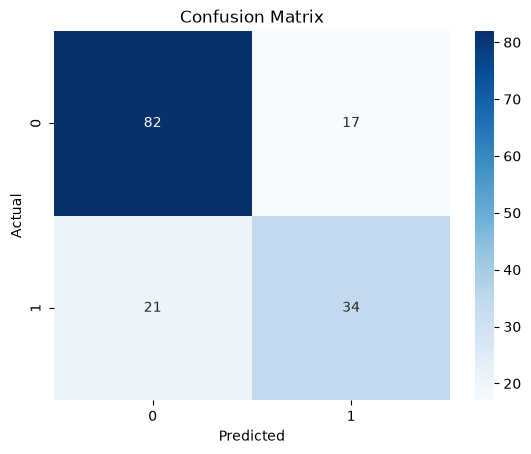

In [17]:
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.83      0.81        99
           1       0.67      0.62      0.64        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154



In [19]:
print("Intercept:", model.intercept_[0])
print("\nCoefficients:")
for feature, coefficient in zip(X.columns, model.coef_[0]):
    print(feature, ":", coefficient)

Intercept: -0.876796359470378

Coefficients:
Pregnancies : 0.22297779667201836
Glucose : 1.1026815303600124
BloodPressure : -0.15153971979020486
SkinThickness : 0.06883608033412902
Insulin : -0.13825212992427072
BMI : 0.6888391878872977
DiabetesPedigreeFunction : 0.20363473051913358
Age : 0.39240956082462786


In [20]:
probabilities = model.predict_proba(X_test_scaled)
print("First 10 predictions:")
for i in range(10):
    print(
        "Actual:", y_test.iloc[i],
        "| Predicted:", y_pred[i],
        "| Probability of diabetes:", round(probabilities[i][1], 4)
    )

First 10 predictions:
Actual: 0 | Predicted: 0 | Probability of diabetes: 0.2735
Actual: 0 | Predicted: 0 | Probability of diabetes: 0.1673
Actual: 0 | Predicted: 0 | Probability of diabetes: 0.1072
Actual: 0 | Predicted: 0 | Probability of diabetes: 0.1541
Actual: 0 | Predicted: 0 | Probability of diabetes: 0.4625
Actual: 0 | Predicted: 0 | Probability of diabetes: 0.4344
Actual: 0 | Predicted: 0 | Probability of diabetes: 0.014
Actual: 0 | Predicted: 0 | Probability of diabetes: 0.3839
Actual: 0 | Predicted: 1 | Probability of diabetes: 0.5755
Actual: 0 | Predicted: 1 | Probability of diabetes: 0.762


In [21]:
new_patient = pd.DataFrame({
    "Pregnancies": [2],
    "Glucose": [140],
    "BloodPressure": [70],
    "SkinThickness": [30],
    "Insulin": [100],
    "BMI": [32.0],
    "DiabetesPedigreeFunction": [0.5],
    "Age": [35]
})
print(new_patient)

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            2      140             70             30      100  32.0   

   DiabetesPedigreeFunction  Age  
0                       0.5   35  


In [22]:
new_patient_scaled = scaler.transform(new_patient)
prediction = model.predict(new_patient_scaled)
probability = model.predict_proba(new_patient_scaled)
print("Prediction:", prediction[0])
print("Probability of diabetes:", round(probability[0][1], 4))
if prediction[0] == 1:
    print("Person is predicted to be susceptible to diabetes.")
else:
    print("Person is predicted not to be susceptible to diabetes.")

Prediction: 0
Probability of diabetes: 0.4576
Person is predicted not to be susceptible to diabetes.


In [23]:
print("Model Accuracy:", round(accuracy * 100, 2), "%")
if prediction[0] == 1:
    print("The new patient is predicted to be susceptible to diabetes.")
else:
    print("The new patient is predicted not to be susceptible to diabetes.")

Model Accuracy: 75.32 %
The new patient is predicted not to be susceptible to diabetes.
